# Assignment 03: Customer Churn Prediction with a Tuned Neural Network

**Name:** Numair Fahad

**Role:** AI/ML Intern

**Company:** Zynvex Solutions

**GitHub:** https://github.com/numair-2003/AIML-Internship-NumairFahad

This assignment is an end-to-end **deep learning project** focused on **predicting customer churn**. Using a **real-world Telco Customer Churn dataset**, a complete neural network workflow is applied — from **data loading and cleaning** to **preprocessing**, **baseline model training**, **model tuning**, **model evaluation**, and **saving the model for reuse**.

## **1. Data Loading**

The **Telco Customer Churn dataset** is loaded into a Pandas DataFrame for analysis. It contains **customer demographics**, **account information**, **services subscribed**, and **whether the customer churned or not**.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## **2. Data Exploration and Cleaning**

The dataset is **inspected** to understand its **structure**, **data types**, **missing values**, and **class balance**. The **TotalCharges** feature is stored as **text** and contains **a few blank entries**, which are handled appropriately.

In [7]:
print("Shape of the dataset:", df.shape)
print("\nFeature types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate values:", df.duplicated().sum())
print("\nChurn value counts:\n", df["Churn"].value_counts())
print("\nChurn percentage:\n", df["Churn"].value_counts(normalize=True).round(4) * 100)


Shape of the dataset: (7043, 21)

Feature types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0


In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing values in TotalCharges after converting to numeric form: ", df["TotalCharges"].isnull().sum())

df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)
print("Shape after cleaning data: ", df.shape)

Missing values in TotalCharges after converting to numeric form:  11
Shape after cleaning data:  (7032, 21)


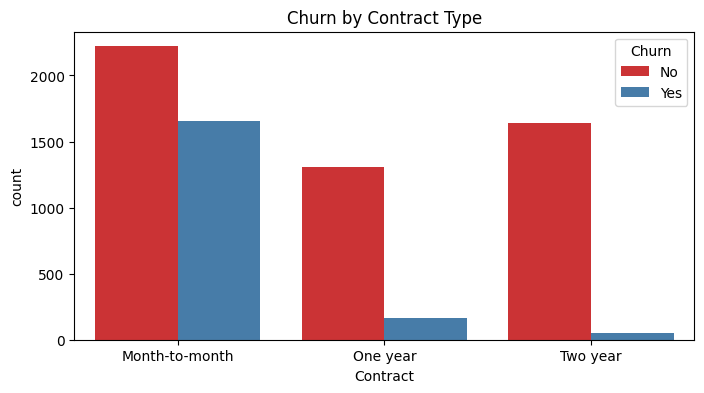

In [9]:
plt.figure(figsize=(8, 4))

sns.countplot(x="Contract", hue="Churn", data=df, palette="Set1")
plt.title("Churn by Contract Type")

plt.show()

### **Interpretation:**

**Initially**, the dataset contained **7,043 rows** and **21 columns**. **After converting TotalCharges to numeric form**, **11 missing values** were **detected** and **removed**, resulting in a **cleaned shape** of **(7,032, 21)**. There are **no duplicate rows**.

The **target variable Churn** is **imbalanced** because:

1. **No** -> **73.46%**
2. **Yes** -> **26.54%**

The **count plot** clearly shows that **customers with a Month-to-month contract** have a **much higher churn rate** compared to those with One year or Two year contracts, which infers that **contract type** is a **strong predictor of churn**.

## **3. Preprocessing for a Neural Network**

In this section, **all categorical features** of the dataset are **encoded**, **numeric features** are **scaled**, and **data is split** into **training** and **test sets**.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = df.drop("customerID", axis=1)

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

binary_columns = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
label_encode = LabelEncoder()
for col in binary_columns:
    df[col] = label_encode.fit_transform(df[col])

multi_columns = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"]

df = pd.get_dummies(df, columns=multi_columns, drop_first=True)

X = df.drop("Churn", axis=1)
y = df["Churn"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape: ", X_train.shape)
print("Test set shape: ", X_test.shape)

Training set shape:  (5625, 30)
Test set shape:  (1407, 30)


### **Interpretation:**

- **customerID** feature is dropped since it is **only an identifier** and has **no predictive value**.

- **Binary columns** including **gender**, **Partner**, **Dependents**, **PhoneService**, and **PaperlessBilling** are **label-encoded** because they comprise **only two categories**. Therefore, a **simple 0/1 mapping** is preferred in this case.

- **Multi-category columns** including **MultipleLines**, **InternetService**, **Contract**, **PaymentMethod**, **etc.** are **one-hot encoded** with **drop_first=True** as they have **no natural order**. This **prevents the model** from **assuming a false ranking between categories**.

- **StandardScaler** is applied to ensure **all numeric features** are **on a similar scale**, which helps the neural network **train more effectively**.

- **Stratified train-test split** is implemented to **preserve the same class distribution of churn** in **both training and test sets**.


## **4. Building and Training a Baseline Model**

In this stage, a **simple Keras Sequential model** consisting of **at least two hidden Dense layers** is **built** and **trained** as a **baseline**.

In [11]:
from tensorflow import keras
from tensorflow.keras import layers

baseline_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

baseline_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_baseline = baseline_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

test_loss, test_accuracy = baseline_model.evaluate(X_test, y_test, verbose=0)
print("Baseline Test Accuracy: ", round(test_accuracy, 4))

Baseline Test Accuracy:  0.7747


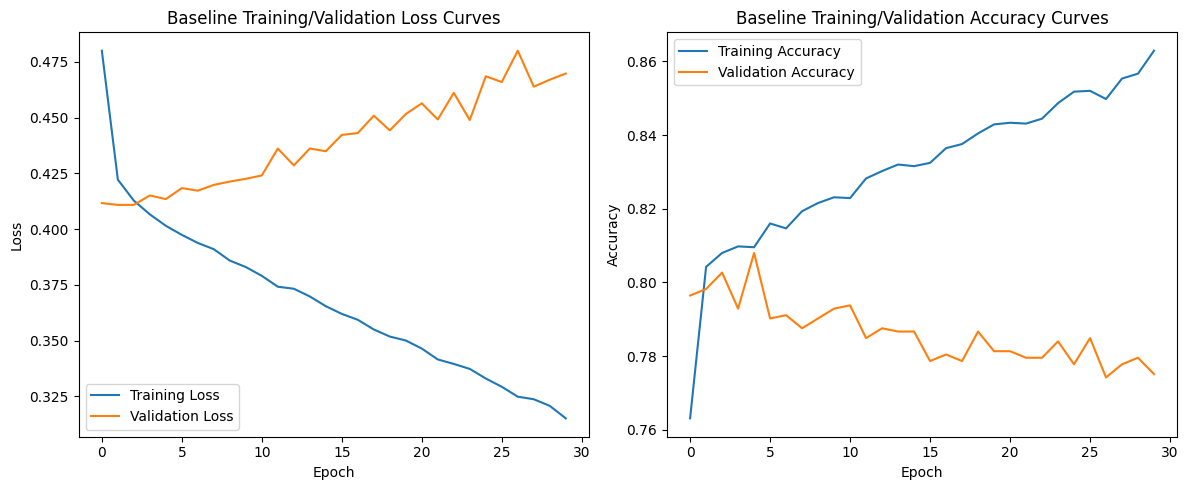

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_baseline.history["loss"], label="Training Loss")
plt.plot(history_baseline.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Baseline Training/Validation Loss Curves")

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history["accuracy"], label="Training Accuracy")
plt.plot(history_baseline.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Baseline Training/Validation Accuracy Curves")

plt.tight_layout()
plt.show()

### **Interpretation:**

The **baseline model** achieves a **test accuracy** of **0.7747**.

Observing the above baseline loss and accuracy curves:

- **Training loss** **gradually decreases**, which shows that the model is **learning** from the **training data**.

- **Validation loss** **begins to increase  after a few epochs**, whereas **training loss continues to fall**. This is a clear indication of **overfitting**.

- **Training accuracy continues to rise**, yet **validation accuracy increases early and then declines**.

As a whole, the **baseline model performs reasonably well**, but **shows clear and obvious signs of overfitting**, which means that **model tuning techniques** (e.g. **Dropout** and **Early Stopping**) are required to **improve model generalization**.

## **5. Model Tuning**

The **baseline model's performance** is improved using **Dropout** and **Early Stopping**.

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

tuned_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

tuned_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_tuned = tuned_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

tuned_loss, tuned_accuracy = tuned_model.evaluate(X_test, y_test, verbose=0)
print("Tuned Test Accuracy: ", round(tuned_accuracy, 4))
print("Baseline Test Accuracy: ", round(test_accuracy, 4))

Tuned Test Accuracy:  0.796
Baseline Test Accuracy:  0.7747


### **Before/After Comparison:**

The **tuned model** (using **both Dropout and Early Stopping**) **improved and raised the test accuracy** from **0.7747 to 0.7960**, which shows that the **tuning techniques successfully minimized overfitting** and **helped the model generalize better on unseen data**.

### **6. Proper Model Evaluation**

**Precision**, **recall**, **F1-score**, and **a confusion matrix** are **reported on the test set** for the **best model**.

Precision:  0.633
Recall:  0.5535
F1-Score:  0.5906

Classification Report: 
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1033
           1       0.63      0.55      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



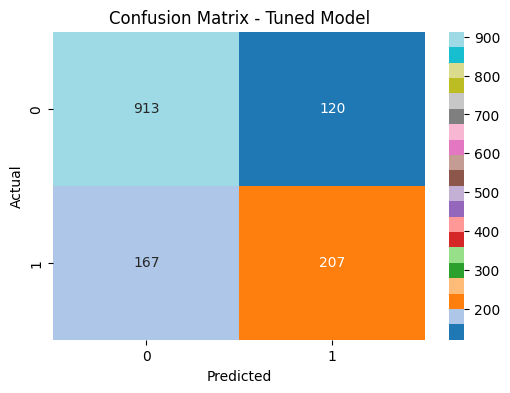

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

y_pred_prob = tuned_model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("Precision: ", round(precision_score(y_test, y_pred), 4))
print("Recall: ", round(recall_score(y_test, y_pred), 4))
print("F1-Score: ", round(f1_score(y_test, y_pred), 4))

print("\nClassification Report: ")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt="d", cmap="tab20")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Model")

plt.show()

### **Did accuracy alone would have been misleading here, provided the class balance determined in Step 2?**

**Yes**, **accuracy alone** would have been **misleading here**. Since the given **dataset is imbalanced**, **consisting of about 73% non-churners**, a model that **mostly predicts “No Churn”** can **still achieve high accuracy** while **failing to correctly identify many actual churners**, which is why **precision**, **recall**, and **F1-score** are considered **more informative in this case**.

## **7. Saving and Predicting the Model**

The **best model** is **saved**, and a **simple prediction function** is created for **a new**, **hypothetical customer**.

In [15]:
tuned_model.save("churn_model.keras")
print("Model saved as churn_model.keras successfully.")

Model saved as churn_model.keras successfully.


In [16]:
def predict_churn(model, customer_features):
    """
    customer_features should be a 2D scaled array (with same scaling as training data).
    """
    prob = model.predict(customer_features, verbose=0)[0][0]
    prediction = "Churn" if prob > 0.5 else "No Churn"
    return prediction, round(float(prob), 4)

loaded_model = keras.models.load_model("churn_model.keras")
sample = X_test[0:1]
result, probability = predict_churn(loaded_model, sample)

print("Prediction: ", result)
print("Churn Probability: ", probability)

Prediction:  No Churn
Churn Probability:  0.0141


## **8. CNN vs RNN**

- A **CNN** (**Convolutional Neural Network**) is preferred when **data has a spatial structure**, such as **images**. CNNs make use of **filters** to **detect local patterns** like **edges** and **textures**; therefore, making them ideal for **image classification** or **object detection**.

- An **RNN** (**Recurrent Neural Network**) is suitable for **sequential data** and when **order matters**, such as **textual** or **time-series data**. RNNs **maintain memory of previous inputs**, which makes them beneficial for tasks such as **sentiment analysis**, **language translation**, or **stock price forecasting**.

In [17]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/numair-2003/AIML-Internship-NumairFahad.git

Mounted at /content/drive
Cloning into 'AIML-Internship-NumairFahad'...
remote: Enumerating objects: 117, done.
remote: Counting objects: 100% (117/117), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 117 (delta 55), reused 56 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (117/117), 1.51 MiB | 17.75 MiB/s, done.
Resolving deltas: 100% (55/55), done.


In [ ]:
!cp "/content/drive/MyDrive/Colab Notebooks/Assignment3_NumairFahad.ipynb" "/content/AIML-Internship-NumairFahad/"